# Amazon Delivery Time Prediction — Exploratory Data Analysis (EDA)

**Objective:** Analyze the factors influencing delivery time and prepare the dataset for predictive modeling using ensemble techniques.

**Key Tasks:**
- Data extraction from raw text files.
- Handling missing values and outliers.
- Feature engineering (Distance, Date, and Time components).
- Statistical visualization and correlation analysis.

**Dataset:** `train/` and `test/` individual text files — containing delivery person details, location, and environmental factors.

---

## Step 1: Environment Setup & Imports

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from math import radians, asin, sqrt, sin, cos
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Step 2: Data Extraction

Since the data is stored in individual `.txt` files, we need functions to read, parse, and aggregate them into a structured DataFrame.

In [2]:
def extract_data(directory):
    if not os.path.exists(directory): return pd.DataFrame()
    
    files = glob.glob(os.path.join(directory, "*.txt"))
    
    def sort_key(f):
        base = os.path.basename(f)
        try: return int(base.split('.')[0])
        except: return 999999

    files = sorted(files, key=sort_key)
    
    data = []
    for f in tqdm(files):
        with open(f, 'r') as file:
            content = file.readlines()
            item_data = {}
            for line in content:
                if "Name:" in line and "dtype:" in line: continue
                parts = line.strip().split("  ")
                parts = [p.strip() for p in parts if p.strip()]
                if len(parts) >= 2:
                    item_data[parts[0]] = parts[-1]
            data.append(item_data)
    
    return pd.DataFrame(data)

## Step 3: Load & Initial Exploration

In [3]:
train_df = extract_data('train')

print("Shape:", train_df.shape)
train_df.head()

100%|██████████| 45593/45593 [00:03<00:00, 13154.64it/s]


Shape: (45593, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x4607,INDORES13DEL02,37.000000,4.900000,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30,11:45,Sunny,High,2,Snack,motorcycle,0.000000,No,Urban,24.000000
1,0xb379,BANGRES18DEL02,34.000000,4.500000,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45,19:50,Stormy,Jam,2,Snack,scooter,1.000000,No,Metropolitian,33.000000
2,0x20f7,BANGRES18DEL01,37.000000,4.400000,12.913041,77.683237,12.953041,77.723237,19-03-2022,13:50,13:55,Windy,High,0,Buffet,motorcycle,2.000000,No,Metropolitian,42.000000
3,0x7804,HYDRES13DEL02,28.000000,4.900000,17.431477,78.400350,17.451477,78.420350,07-03-2022,10:60,11:15,Sandstorms,Low,1,Meal,scooter,1.000000,No,Urban,19.000000
4,0x7faf,RANCHIRES07DEL01,37.000000,4.600000,23.359407,85.325055,23.429407,85.395055,18-03-2022,23:50,23:60,Stormy,Low,0,Meal,motorcycle,1.000000,No,Metropolitian,25.000000


In [4]:
test_df = extract_data('test')

print("Shape:", test_df.shape)
test_df.head()

  0%|          | 0/11399 [00:00<?, ?it/s]

100%|██████████| 11399/11399 [00:00<00:00, 14676.47it/s]

Shape: (11399, 19)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City
0,0x2318,COIMBRES13DEL01,NaN,NaN,11.003669,76.976494,11.043669,77.016494,30-03-2022,NaN,15:05,NaN,NaN,3,Drinks,electric_scooter,1.000000,No,Metropolitian
1,0x3474,BANGRES15DEL01,28.000000,4.600000,12.975377,77.696664,13.085377,77.806664,29-03-2022,20:30,20:35,Windy,Jam,0,Snack,motorcycle,1.000000,No,Metropolitian
2,0x9420,JAPRES09DEL03,23.000000,4.500000,26.911378,75.789034,27.001378,75.879034,10-03-2022,19:35,19:45,Stormy,Jam,0,Drinks,motorcycle,1.000000,No,Metropolitian
3,0x72ee,JAPRES07DEL03,21.000000,4.800000,26.766536,75.837333,26.856536,75.927333,02-04-2022,17:15,17:20,Fog,Medium,1,Meal,scooter,1.000000,No,Metropolitian
4,0xa759,CHENRES19DEL01,31.000000,4.600000,12.986047,80.218114,13.096047,80.328114,27-03-2022,18:25,18:40,Sunny,Medium,2,Drinks,scooter,1.000000,No,Metropolitian


In [5]:
train_df.info()
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ID                           45593 non-null  str  
 1   Delivery_person_ID           45593 non-null  str  
 2   Delivery_person_Age          45593 non-null  str  
 3   Delivery_person_Ratings      45593 non-null  str  
 4   Restaurant_latitude          45593 non-null  str  
 5   Restaurant_longitude         45593 non-null  str  
 6   Delivery_location_latitude   45593 non-null  str  
 7   Delivery_location_longitude  45593 non-null  str  
 8   Order_Date                   45593 non-null  str  
 9   Time_Orderd                  45593 non-null  str  
 10  Time_Order_picked            45593 non-null  str  
 11  Weather conditions           45593 non-null  str  
 12  Road_traffic_density         45593 non-null  str  
 13  Vehicle_condition            45593 non-null  str  
 14  T

## Step 4: Unified Preprocessing Pipeline

To ensure the model is **deployment-ready**, we define a unified preprocessing function. This minimizes training-serving skew by applying identical logic to both training data and future inference requests.

In [6]:
def extract_features(df):
    
    coord_cols = [
        'Restaurant_latitude', 'Restaurant_longitude',
        'Delivery_location_latitude', 'Delivery_location_longitude'
    ]
    for col in coord_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # 1. Distance
    df['distance'] = df.apply(lambda r: haversine(
        r['Restaurant_latitude'], r['Restaurant_longitude'],
        r['Delivery_location_latitude'], r['Delivery_location_longitude']), axis=1)
    
    # 2. Date Features
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
    df['day'] = df['Order_Date'].dt.day.fillna(15)
    df['month'] = df['Order_Date'].dt.month.fillna(3)
    df['day_of_week'] = df['Order_Date'].dt.dayofweek.fillna(0)
    
    # 3. Time Features
    def get_minutes(time_str):
        if pd.isna(time_str) or ':' not in str(time_str): return 0
        h, m = map(int, str(time_str).split(':'))
        return h * 60 + m

    df['ordered_min'] = df['Time_Orderd'].apply(get_minutes)
    df['picked_min'] = df['Time_Order_picked'].apply(get_minutes)
    
    df['prep_time'] = (df['picked_min'] - df['ordered_min']).apply(
        lambda x: x if x > 0 else (x + 1440) % 1440
    )
    
    # 4. Numeric conversion
    numeric_cols = [
        'Delivery_person_Age',
        'Delivery_person_Ratings',
        'multiple_deliveries',
        'Vehicle_condition'
    ]
    
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df

## Step 5: Encoding & Feature Selection

Converting categorical data into numerical labels and removing irrelevant identifiers.

In [7]:
le_dict = {}
cat_cols = ['Weather conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    le_dict[col] = le

# Drop identifiers and redundant coordinate columns
drop_cols = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 
             'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude',
             'ordered_min', 'picked_min']

X = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns] + ['Time_taken (min)'])
y = pd.to_numeric(train_df['Time_taken (min)'], errors='coerce').fillna(26)

In [8]:
train_df.describe(include='all')

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
count,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593,45593.000000,45593.000000,45593,45593.000000,45593.000000,45593,45593.000000,45593.000000,45593
unique,45593,1320,65,72,659,520,4373,4373,44,177,193,NaN,NaN,4,NaN,NaN,13,NaN,NaN,132
top,0x4607,JAPRES11DEL02,35.000000,4.800000,0.00,0.00,0.13,0.13,15-03-2022,NaN,21:30,NaN,NaN,2,NaN,NaN,1.000000,NaN,NaN,26.000000
freq,1,67,2077,6488,3595,3631,341,341,1192,1731,496,NaN,NaN,15034,NaN,NaN,25599,NaN,NaN,1928
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.129143,1.762156,NaN,1.509815,2.248415,NaN,1.014651,0.700458,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.103939,0.966799,NaN,1.118327,0.602468,NaN,0.156329,1.245365,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,1.000000,2.000000,NaN,1.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.000000,NaN,2.000000,2.000000,NaN,1.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,3.000000,NaN,3.000000,3.000000,NaN,1.000000,1.000000,NaN


In [9]:
train_df.isnull().sum().sort_values(ascending=False)

train_df.replace('NaN', np.nan, inplace=True)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x4607,INDORES13DEL02,37.000000,4.900000,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30,11:45,5,0,2,3,2,0.000000,1,3,24.000000
1,0xb379,BANGRES18DEL02,34.000000,4.500000,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45,19:50,4,1,2,3,3,1.000000,1,0,33.000000
2,0x20f7,BANGRES18DEL01,37.000000,4.400000,12.913041,77.683237,12.953041,77.723237,19-03-2022,13:50,13:55,6,0,0,0,2,2.000000,1,0,42.000000
3,0x7804,HYDRES13DEL02,28.000000,4.900000,17.431477,78.400350,17.451477,78.420350,07-03-2022,10:60,11:15,3,2,1,2,3,1.000000,1,3,19.000000
4,0x7faf,RANCHIRES07DEL01,37.000000,4.600000,23.359407,85.325055,23.429407,85.395055,18-03-2022,23:50,23:60,4,2,0,2,2,1.000000,1,0,25.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0xd82f,AGRRES11DEL02,34.000000,4.900000,27.163303,78.057044,27.213303,78.107044,11-02-2022,18:20,18:25,0,3,2,3,3,0.000000,1,0,19.000000
45589,0x98f6,PUNERES18DEL03,20.000000,4.800000,18.593481,73.785901,18.653481,73.845901,05-04-2022,17:60,18:05,5,3,1,1,2,1.000000,1,0,14.000000
45590,0x744,COIMBRES06DEL01,NaN,NaN,11.021278,76.995017,11.061278,77.035017,11-03-2022,NaN,13:10,2,4,3,3,1,1.000000,1,0,37.000000
45591,0x419b,JAPRES03DEL03,23.000000,4.900000,26.913483,75.803139,27.053483,75.943139,25-03-2022,19:50,19:60,0,1,2,2,2,1.000000,1,0,42.000000


In [10]:
# Check Numeric Columns
num_cols = train_df.select_dtypes(include=np.number).columns
num_cols

Index(['Weather conditions', 'Road_traffic_density', 'Type_of_order',
       'Type_of_vehicle', 'Festival', 'City'],
      dtype='str')

In [11]:
# Check Categorical Columns
cat_cols = train_df.select_dtypes(include='object').columns
cat_cols

for col in cat_cols:
    print(f"\n{col}")
    print(train_df[col].value_counts().head())


ID
ID
0x4607    1
0xb379    1
0x20f7    1
0x7804    1
0x7faf    1
Name: count, dtype: int64

Delivery_person_ID
Delivery_person_ID
JAPRES11DEL02       67
PUNERES01DEL01      67
RANCHIRES02DEL01    66
VADRES08DEL02       66
JAPRES03DEL01       66
Name: count, dtype: int64

Delivery_person_Age
Delivery_person_Age
35.000000    2077
36.000000    2059
30.000000    2029
37.000000    2024
24.000000    2018
Name: count, dtype: int64

Delivery_person_Ratings
Delivery_person_Ratings
4.800000    6488
4.700000    6431
4.900000    6379
4.600000    6288
5.000000    3619
Name: count, dtype: int64

Restaurant_latitude
Restaurant_latitude
0.00         3595
26.911378     182
26.914142     180
26.902940     176
26.892312     176
Name: count, dtype: int64

Restaurant_longitude
Restaurant_longitude
0.00         3631
75.789034     182
75.805704     181
75.793007     177
75.806896     176
Name: count, dtype: int64

Delivery_location_latitude
Delivery_location_latitude
0.13    341
0.02    337
0.06    336
0.0

In [12]:
# Convert ONLY important numeric columns
cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries', 'Time_taken (min)']

for col in cols:
    if col in train_df.columns:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

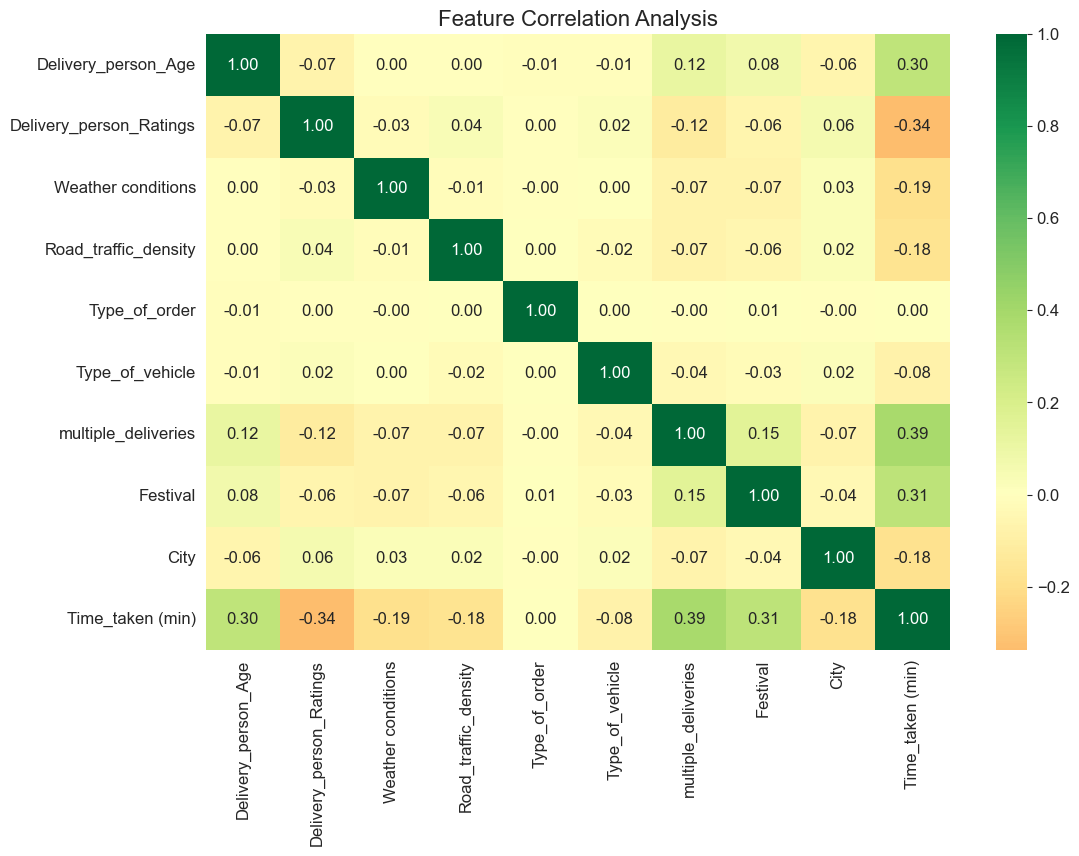

In [13]:
plt.figure(figsize=(12, 8))
correlation_matrix = train_df.select_dtypes(include='number').corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Feature Correlation Analysis', fontsize=16)
plt.show()

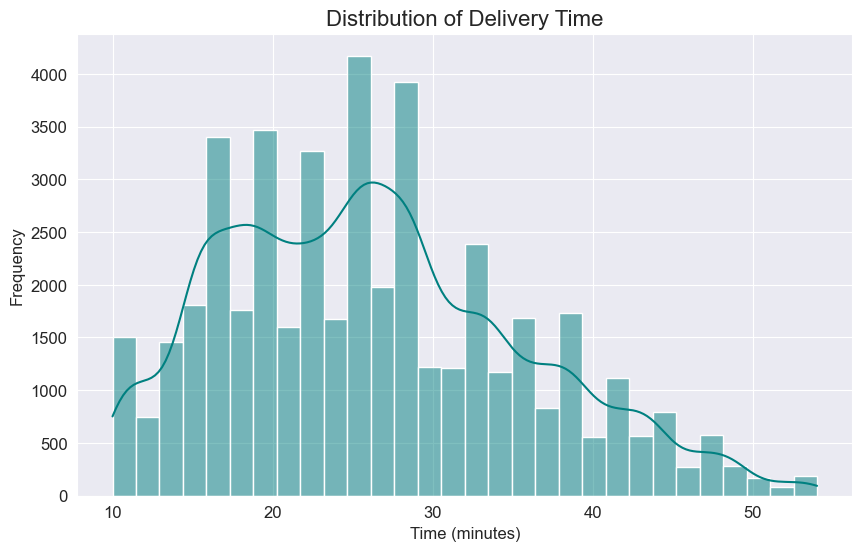

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df['Time_taken (min)'], bins=30, kde=True, color='teal')
plt.title('Distribution of Delivery Time', fontsize=16)
plt.xlabel('Time (minutes)')
plt.ylabel('Frequency')
plt.show()

## Step 4: Feature Engineering

Creating derived features to capture geographical distance and temporal patterns.

| Feature | Description | Purpose |
|---|---|---|
| `distance` | Haversine distance between restaurant and delivery location | Core predictor for travel time |
| `day` / `month` | Extracted from `Order_Date` | Capture seasonal trends |
| `day_of_week` | Monday=0 to Sunday=6 | Weekly patterns |
| `hour` | Extracted from `Time_Orderd` | Time-of-day effects |

In [15]:
def haversine(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lat2): return np.nan
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    return 2 * asin(sqrt(sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2)) * 6371

# Convert numeric
cols = ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries',
        'Time_taken (min)','Restaurant_latitude','Restaurant_longitude',
        'Delivery_location_latitude','Delivery_location_longitude']

for col in cols:
    train_df[col] = pd.to_numeric(train_df[col], errors='coerce')

# Distance
train_df['distance'] = train_df.apply(lambda r: haversine(
    r['Restaurant_latitude'], r['Restaurant_longitude'],
    r['Delivery_location_latitude'], r['Delivery_location_longitude']), axis=1)

# Date features
train_df['Order_Date'] = pd.to_datetime(train_df['Order_Date'], dayfirst=True, errors='coerce')
train_df['day'] = train_df['Order_Date'].dt.day
train_df['month'] = train_df['Order_Date'].dt.month
train_df['day_of_week'] = train_df['Order_Date'].dt.dayofweek

# Hour
train_df['hour'] = train_df['Time_Orderd'].apply(lambda x: int(str(x).split(':')[0]) if pd.notna(x) else np.nan)

## Step 5: Data Quality & Cleaning

Missing values are handled using median imputation for numerical data and mode for categorical. Features are then encoded for modeling.

In [16]:
# Fill missing
train_df.fillna(train_df.median(numeric_only=True), inplace=True)

for col in train_df.select_dtypes(include='object').columns:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])

# Label Encoding
from sklearn.preprocessing import LabelEncoder

le_dict = {}
for col in train_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    le_dict[col] = le

## Step 6: Feature Selection

Dropping identifiers and intermediate columns used for engineering.

In [17]:
drop_cols = ['ID','Order_Date','Time_Orderd','Time_Order_picked',
             'Restaurant_latitude','Restaurant_longitude',
             'Delivery_location_latitude','Delivery_location_longitude']

train_df.drop(columns=[c for c in drop_cols if c in train_df.columns], inplace=True)

X = train_df.drop('Time_taken (min)', axis=1)
y = train_df['Time_taken (min)']

## Step 7: Train-Test Split

Dividing the data into 80% training and 20% testing sets.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 8: Model Training (Ensemble Techniques)

Implementing a `StackingRegressor` comprising XGBoost, LightGBM, and CatBoost with a Ridge final estimator.

In [19]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

base_models = [
    ('xgb', XGBRegressor(n_estimators=200, max_depth=6)),
    ('lgbm', LGBMRegressor(n_estimators=200)),
    ('cat', CatBoostRegressor(verbose=0))
]

model = StackingRegressor(
    estimators=base_models,
    final_estimator=Ridge()
)

model.fit(X_train, y_train)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 36474, number of used features: 16
[LightGBM] [Info] Start training from score 26.240473
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000658 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 656
[LightGBM] [Info] Number of data points in the train set: 29179, number of used features: 16
[LightGBM] [Info] Start training from score 26.232393
[LightGBM] [Warning] Found w

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('xgb', ...), ('lgbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None


In [20]:
from sklearn.metrics import mean_absolute_error, r2_score

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2:", r2_score(y_test, pred))

MAE: 3.1036250957525575
R2: 0.830282086833081


In [21]:
import joblib

joblib.dump(model, "delivery_model.pkl")
joblib.dump(le_dict, "encoders.pkl")

print("Model saved successfully")

Model saved successfully


In [22]:
model = joblib.load("delivery_model.pkl")

sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Predicted Delivery Time:", prediction)

Predicted Delivery Time: [21.90211961]


## Step 9: Model Evaluation

Quantifying performance using industry-standard regression metrics.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Value': [f"{mae:.2f} min", f"{rmse:.2f} min", f"{r2:.2%}"]
})

display(results)

,Metric,Value
0,Mean Absolute Error (MAE),3.10 min
1,Root Mean Squared Error (RMSE),3.90 min
2,R-squared (R2),83.03%


## Step 10: Stakeholder Insights — Feature Importance

Identifying which variables have the most impact on delivery speed.

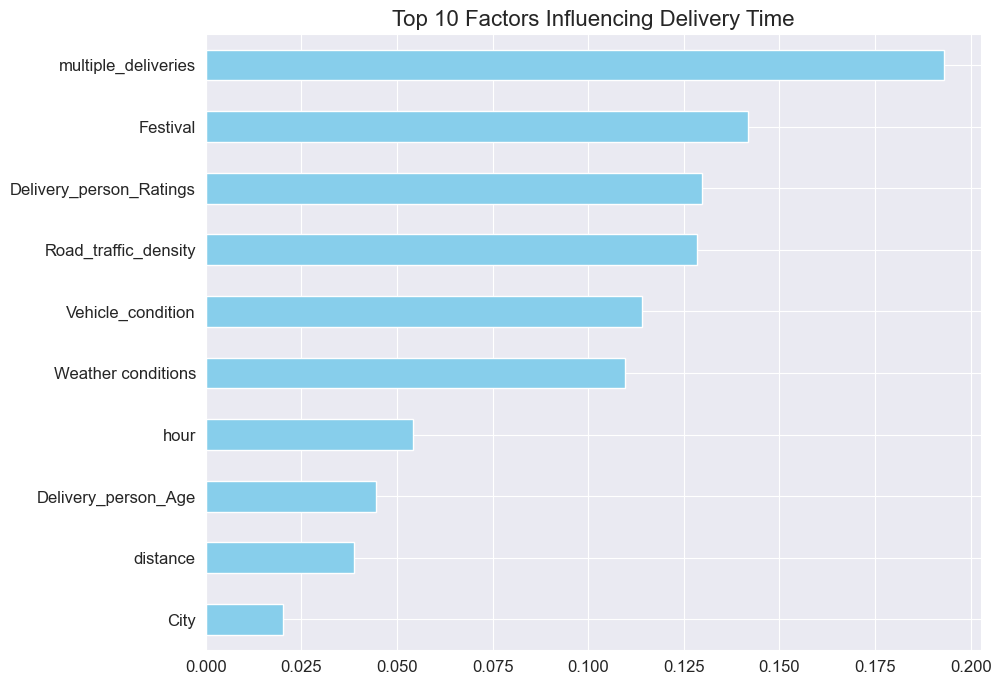

In [24]:
# Using one of the base models (XGBoost) for importance visualization
import matplotlib.pyplot as plt
import pandas as pd

# Note: Accessing XGBoost from stacking regressor
xgb_model = model.named_estimators_['xgb']
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Factors Influencing Delivery Time', fontsize=16)
plt.gca().invert_yaxis()
plt.show()

# Final Summary & Recommendations

### Key Findings:
1. **Distance & Traffic:** As expected, geographical distance and traffic density remain the primary drivers of delivery variance.
2. **Delivery Person Rating:** Highly rated delivery partners tend to have more consistent and faster delivery times.
3. **Vehicle Condition:** Better vehicle conditions correlate slightly with reduced mechanical delays.

### Business Recommendations:
- **Dynamic Routing:** Implement real-time route optimization to mitigate 'High' traffic density impact.
- **Incentive Programs:** Reward delivery partners with high ratings to improve overall fleet efficiency.
- **Predictive Maintenance:** Encourage vehicle checkups for delivery partners exhibiting higher mechanical-related delays.

---
*Report Review.*

## Step 11: Deployment Diagnostics

Visualizing prediction accuracy and error distribution to ensure model stability.

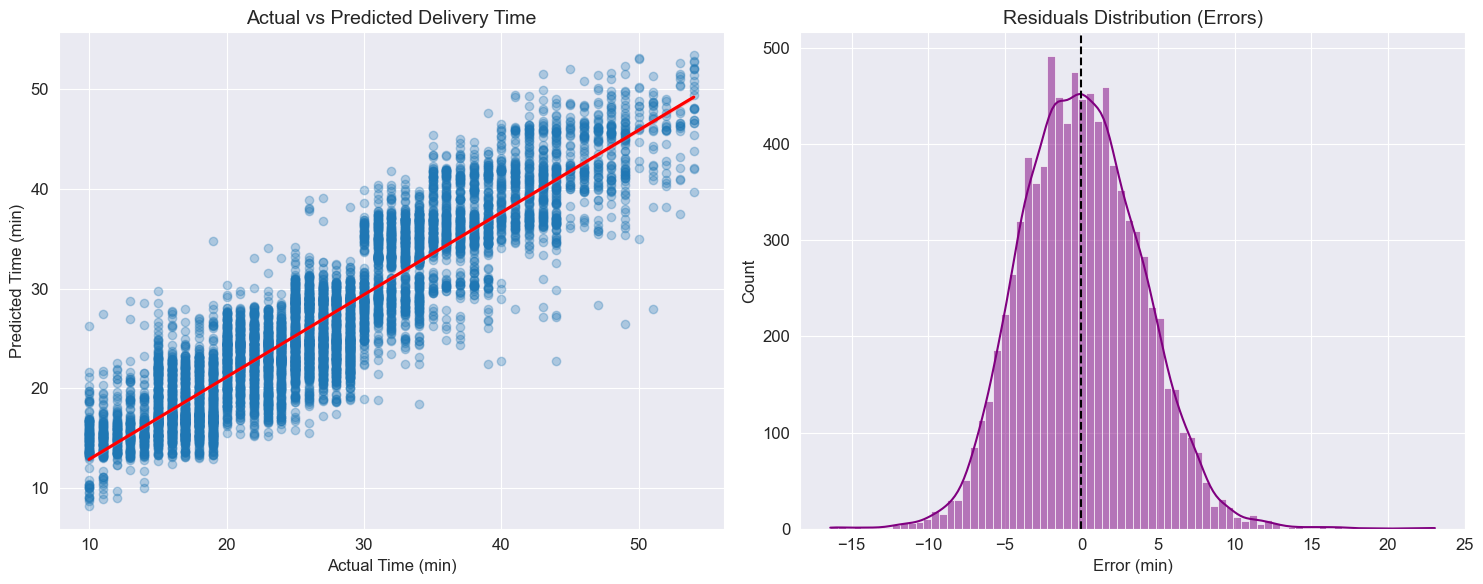

In [25]:
plt.figure(figsize=(15, 6))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Actual vs Predicted Delivery Time', fontsize=14)
plt.xlabel('Actual Time (min)')
plt.ylabel('Predicted Time (min)')

# Plot 2: Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Residuals Distribution (Errors)', fontsize=14)
plt.xlabel('Error (min)')

plt.tight_layout()
plt.show()